# Cosine Similarity Sleeper Model

**Core idea:** Build two prototype TF-IDF vectors from historical scouting reports —
a **Sleeper Vector** (Round 5–7 players who earned a second contract) and a **Bust Vector**
(highly-graded players who failed to earn one). Then measure how closely any new scouting report
resembles each prototype.

**Key question:** Does a high `cos_sleeper − cos_bust` score predict success *independently of the grade*, particularly in the low-grade subgroup where the grade provides weakest signal?

In [1]:
import re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

ROOT     = Path('..')
DATA     = ROOT / 'data' / 'processed' / 'draft_enriched_with_contracts.csv'
OUT_DIR  = ROOT / 'analysis_outputs'
OUT_DIR.mkdir(exist_ok=True)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
VECTORIZER_PARAMS = dict(max_features=1500, ngram_range=(2, 3), min_df=3, sublinear_tf=True)
GROUPS = {
    'Block':    {'OL', 'DT'},
    'Coverage': {'EDGE', 'DB', 'LB'},
    'Skill':    {'WR', 'RB', 'TE', 'UNKNOWN'},
    'QB':       {'QB'},
}
GROUP_COLORS  = {'Block': '#2196F3', 'Coverage': '#4CAF50', 'Skill': '#FF9800', 'QB': '#9C27B0'}
SLEEPER_GRADE = 6.2   # sub-group ceiling for lift analysis
BUST_GRADE    = 6.5   # bust pool floor
CV_SEED       = 42

print('Setup OK')

Setup OK


In [2]:
# ── Load & Preprocess ─────────────────────────────────────────────────────────

raw = pd.read_csv(DATA, low_memory=False)
raw['grade'] = pd.to_numeric(raw['grade'], errors='coerce')
raw = raw[raw['grade'].between(4.0, 8.0)].copy()

for col in ['overview', 'strengths', 'weaknesses']:
    raw[col] = raw[col].fillna('')
raw = raw[(raw['overview'].str.len() + raw['strengths'].str.len() + raw['weaknesses'].str.len()) > 30].copy()

# Label leak fence: hide outcomes after 2021
raw['made_it_contract'] = raw['made_it_contract'].where(raw['year'].between(2014, 2021))

# Draft round
def parse_round(s):
    m = re.search(r'Rnd\s*(\d+)', str(s))
    return int(m.group(1)) if m else None
raw['draft_round'] = raw['drafted'].apply(parse_round)

# ── Text preprocessing (section-tagged, no NLTK download needed) ─────────────
KEEP   = {'high','low','heavy','light','deep','short','long','wide','pass',
           'hard','soft','strong','quick','good','great','up','down','off',
           'out','over','through','above','below'}
CUSTOM = {'prospect','player','players','show','shows','need','needs','ability',
           'also','often','must','well','still','use','get','make','look','help',
           'work','time','year','team','game','continue','develop','development',
           'nfl','draft','college','level','type','project','potential','upside','ceiling'}
PHRASE_BLOCK = ['undrafted free agent','practice squad','free agent','pro bowl','late round']
_stops = (set(ENGLISH_STOP_WORDS) - KEEP) | CUSTOM

_SFXS = [('nesses',''),('ness',''),('ings',''),('ing',''),('ational','ate'),
          ('tion',''),('tions',''),('ers',''),('ier','y'),('ies','y'),
          ('ed',''),('es',''),('s','')]
def _lemma(w):
    for sfx, rep in _SFXS:
        if w.endswith(sfx) and len(w)-len(sfx) > 2:
            return w[:-len(sfx)] + rep
    return w

def _clean(text):
    text = text.lower()
    for p in PHRASE_BLOCK: text = text.replace(p, ' ')
    text = re.sub(r'[\-\u2013\u2014]', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return ' '.join(_lemma(t) for t in text.split() if t not in _stops and len(t) > 1)

def section_tag(row):
    parts = []
    for col, pfx in [('overview','ovr'),('strengths','str'),('weaknesses','wkn')]:
        c = _clean(str(row[col]))
        if c.strip():
            parts.extend(f'{pfx}_{tok}' for tok in c.split())
    return ' '.join(parts)

print('Preprocessing text...')
raw['txt'] = raw.apply(section_tag, axis=1)

# Assign broad group
pos2grp = {p: g for g, ps in GROUPS.items() for p in ps}
raw['broad_group'] = raw['Pos_Group'].map(pos2grp).fillna('Other')

print(f'  {len(raw):,} rows | grade {raw["grade"].min():.2f}–{raw["grade"].max():.2f} '
      f'| median {raw["grade"].median():.2f}')

# Split: labeled training cohort vs prospective (unlabeled)
train_df = raw[raw['year'].between(2014,2021) & raw['made_it_contract'].notna()].copy()
train_df['made_it_contract'] = train_df['made_it_contract'].astype(int)
pro_df   = raw[raw['year'].between(2022,2025)].copy()

print(f'  Training: {len(train_df):,} (pos rate {train_df["made_it_contract"].mean():.1%})')
print(f'  Prospective 2022–2025: {len(pro_df):,}')

Preprocessing text...


  5,564 rows | grade 4.90–7.50 | median 5.82
  Training: 3,239 (pos rate 31.2%)
  Prospective 2022–2025: 1,853


In [3]:
# ── Build TF-IDF and Prototype Vectors ───────────────────────────────────────
#
# Fit the vectorizer ONLY on the training corpus so that prototype vectors and
# per-player vectors all live in the same feature space with no leakage.

vec   = TfidfVectorizer(**VECTORIZER_PARAMS)
X_tr  = vec.fit_transform(train_df['txt'])   # (N_train, V)

# ── Sleeper prototype: Round 5–7 players who earned a second contract ─────────
s_mask = train_df['draft_round'].between(5, 7) & (train_df['made_it_contract'] == 1)
# ── Bust prototype: grade ≥ 6.5 players who did NOT earn a second contract ────
b_mask = (train_df['grade'] >= BUST_GRADE)    & (train_df['made_it_contract'] == 0)

sleeper_proto = np.asarray(X_tr[s_mask.values].mean(axis=0))  # (1, V)
bust_proto    = np.asarray(X_tr[b_mask.values].mean(axis=0))

print(f'Sleeper prototype built from {s_mask.sum()} players  (Rnd 5–7, made 2nd contract)')
print(f'Bust prototype built from    {b_mask.sum()} players  (grade ≥ {BUST_GRADE}, no 2nd contract)')
print(f'TF-IDF vocabulary size: {X_tr.shape[1]}')

# Top-10 terms in each prototype (highest mean TF-IDF weight)
feature_names = vec.get_feature_names_out()
def top_proto_terms(proto, n=10):
    idx = np.argsort(proto.flatten())[::-1][:n]
    return [(feature_names[i].replace('ovr_','').replace('str_','[S] ').replace('wkn_','[W] '), 
             round(float(proto.flatten()[i]), 4)) for i in idx]

print('\nTop-10 terms in Sleeper prototype:')
for t, w in top_proto_terms(sleeper_proto): print(f'  {t:<35} {w}')
print('\nTop-10 terms in Bust prototype:')
for t, w in top_proto_terms(bust_proto): print(f'  {t:<35} {w}')

Sleeper prototype built from 206 players  (Rnd 5–7, made 2nd contract)
Bust prototype built from    57 players  (grade ≥ 6.5, no 2nd contract)
TF-IDF vocabulary size: 1500

Top-10 terms in Sleeper prototype:
  [W] below [W] average               0.0302
  special team                        0.0214
  [S] special [S] team                0.0171
  [W] change [W] direc                0.017
  [S] above [S] average               0.0165
  [S] upper [S] body                  0.0151
  [S] line [S] scrimmage              0.0149
  [W] point [W] attack                0.0144
  [W] short [W] arm                   0.0134
  [S] run [S] support                 0.0131

Top-10 terms in Bust prototype:
  [S] change [S] direc                0.0279
  [S] lower [S] body                  0.0226
  [W] pas [W] rush                    0.021
  early starter                       0.021
  [S] upfield [S] burst               0.0199
  [W] pres [W] coverage               0.0199
  [S] long [S] arm                    0.01

In [4]:
# ── Compute cos_sleeper, cos_bust, cos_diff for every training player ─────────

train_df = train_df.copy().reset_index(drop=True)

cos_s = cosine_similarity(X_tr, sleeper_proto).flatten()
cos_b = cosine_similarity(X_tr, bust_proto).flatten()
cos_d = cos_s - cos_b   # positive  = more sleeper-like; negative = more bust-like

train_df['cos_sleeper'] = cos_s
train_df['cos_bust']    = cos_b
train_df['cos_diff']    = cos_d

# Sanity check: direction of cos_diff by outcome
print('cos_diff by outcome  (mean ± std):')
for outcome in [0, 1]:
    sub = train_df.loc[train_df['made_it_contract'] == outcome, 'cos_diff']
    label = 'Made it (1)' if outcome == 1 else 'Bust    (0)'
    print(f'  {label}:  mean={sub.mean():.4f}  std={sub.std():.4f}  median={sub.median():.4f}')

# Quick t-test to confirm the difference is not noise
from scipy import stats as sp_stats
t, p = sp_stats.ttest_ind(
    train_df.loc[train_df['made_it_contract']==1, 'cos_diff'],
    train_df.loc[train_df['made_it_contract']==0, 'cos_diff'],
    equal_var=False
)
print(f'\n  Welch t-test  t={t:.3f}  p={p:.4f}  '
      f'({"significant at α=0.05" if p < 0.05 else "not significant"})')

cos_diff by outcome  (mean ± std):
  Bust    (0):  mean=0.0275  std=0.0389  median=0.0299
  Made it (1):  mean=0.0311  std=0.0375  median=0.0315

  Welch t-test  t=2.508  p=0.0122  (significant at α=0.05)


In [5]:
# ── Lift Analysis: Grade alone vs Grade + cos_diff in grade < 6.2 subgroup ────
#
# This is the core test.  The grade < 6.2 population is where:
#   (a) the grade has the weakest predictive power (it already says "low")
#   (b) any additional signal from language has the most room to lift precision

low_mask = train_df['grade'] < SLEEPER_GRADE
sub      = train_df[low_mask].copy().reset_index(drop=True)
y        = sub['made_it_contract'].values

cv = StratifiedKFold(n_splits=min(5, int(y.sum())), shuffle=True, random_state=CV_SEED)

def oof_pr_auc(X, y, cv):
    pipe = Pipeline([('sc', StandardScaler()),
                     ('lr', LogisticRegression(class_weight='balanced',
                                               max_iter=2000, solver='liblinear'))])
    oof = cross_val_predict(pipe, X, y, cv=cv, method='predict_proba')[:,1]
    return average_precision_score(y, oof), oof

def p_at_k(y, scores, k=20):
    return float(np.asarray(y)[np.argsort(scores)[::-1][:k]].mean())

pra_g, oof_g = oof_pr_auc(sub[['grade']].values, y, cv)
pra_c, oof_c = oof_pr_auc(sub[['cos_diff']].values, y, cv)
pra_gc, oof_gc = oof_pr_auc(sub[['grade','cos_diff']].values, y, cv)

print(f'Sub-group: grade < {SLEEPER_GRADE}  →  N={len(sub):,}  '
      f'positive rate={y.mean():.1%}  (random baseline PR-AUC ≈ {y.mean():.2f})')
print()
print(f'{"Model":<26}  {"PR-AUC":>8}  {"P@20":>7}  {"Lift vs Grade":>14}')
print('-' * 60)
print(f'{"Grade alone":<26}  {pra_g:>8.4f}  {p_at_k(y, oof_g):>7.3f}  {"—":>14}')
print(f'{"cos_diff alone":<26}  {pra_c:>8.4f}  {p_at_k(y, oof_c):>7.3f}  {pra_c - pra_g:>+14.4f}')
print(f'{"Grade + cos_diff":<26}  {pra_gc:>8.4f}  {p_at_k(y, oof_gc):>7.3f}  {pra_gc - pra_g:>+14.4f}')

Sub-group: grade < 6.2  →  N=2,558  positive rate=23.8%  (random baseline PR-AUC ≈ 0.24)

Model                         PR-AUC     P@20   Lift vs Grade
------------------------------------------------------------
Grade alone                   0.3151    0.250               —
cos_diff alone                0.3109    0.400         -0.0042
Grade + cos_diff              0.3712    0.650         +0.0561


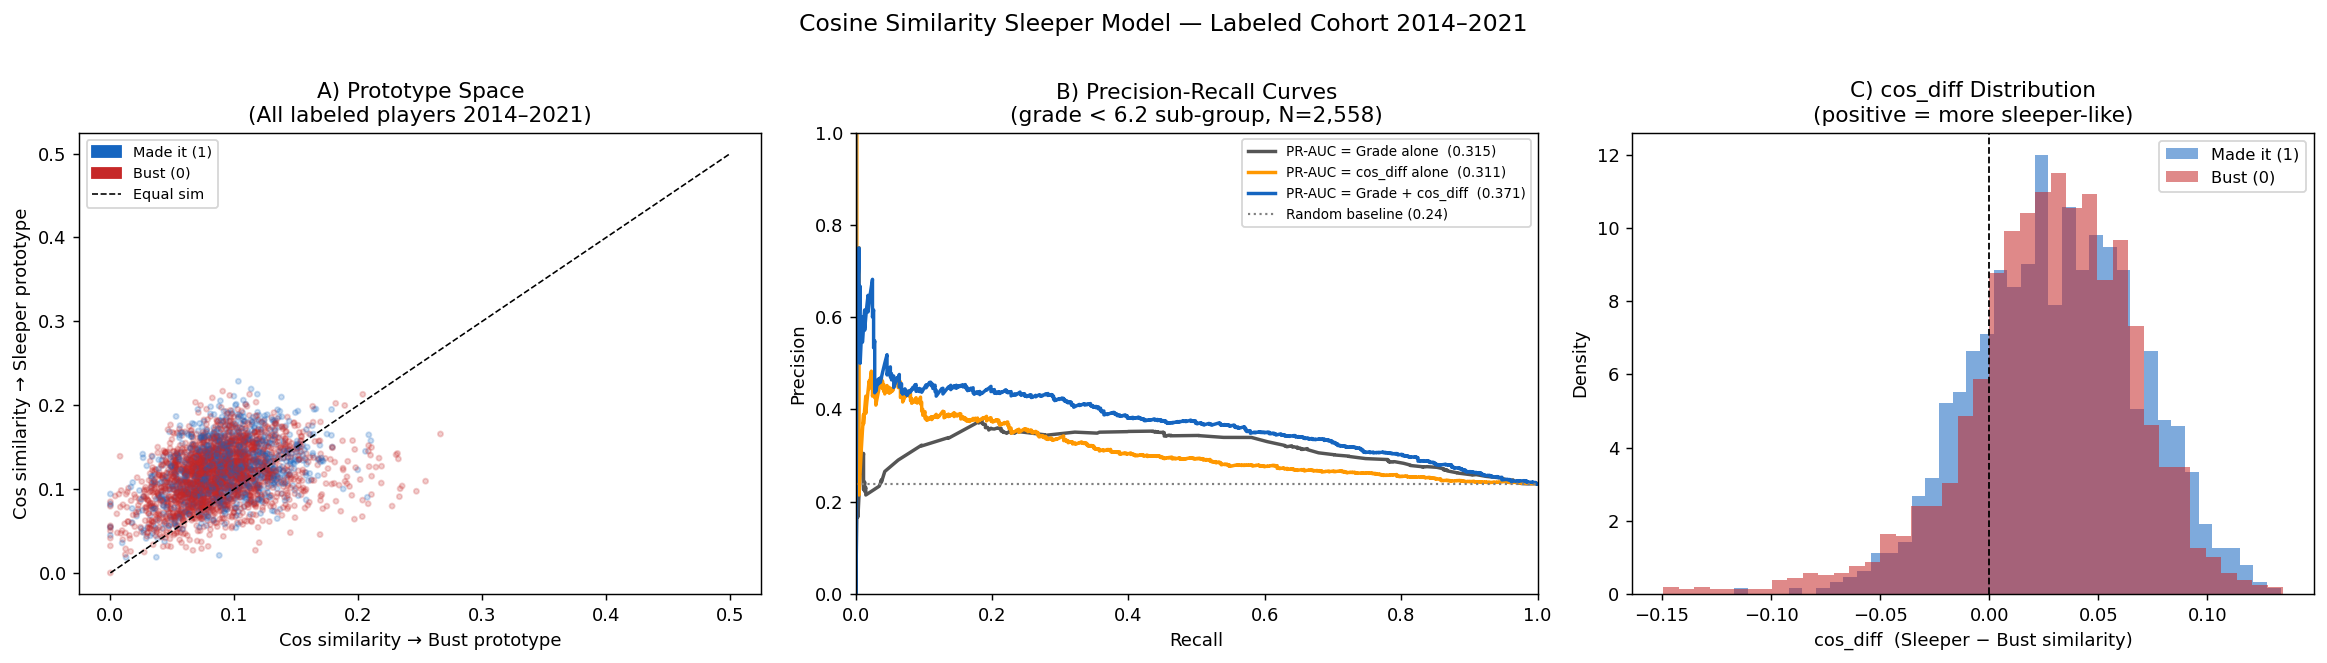

Saved → analysis_outputs/cosine_model_overview.png


In [6]:
# ── Visualisation ─────────────────────────────────────────────────────────────
# Three panels:
#   A) Prototype space (cos_bust vs cos_sleeper), coloured by outcome
#   B) P/R curves for the three models in the low-grade subgroup
#   C) cos_diff distribution split by outcome

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── A) Prototype Space ────────────────────────────────────────────────────────
ax = axes[0]
c_map = train_df['made_it_contract'].map({1: '#1565C0', 0: '#C62828'})
ax.scatter(train_df['cos_bust'], train_df['cos_sleeper'],
           c=c_map, alpha=0.22, s=8, rasterized=True)
ax.plot([0, 0.5], [0, 0.5], 'k--', lw=0.9, label='Equal similarity')
ax.set_xlabel('Cos similarity → Bust prototype')
ax.set_ylabel('Cos similarity → Sleeper prototype')
ax.set_title('A) Prototype Space\n(All labeled players 2014–2021)')
ax.legend(handles=[
    mpatches.Patch(color='#1565C0', label='Made it (1)'),
    mpatches.Patch(color='#C62828', label='Bust (0)'),
    plt.Line2D([0],[0], color='k', ls='--', lw=0.9, label='Equal sim'),
], fontsize=8)

# ── B) Precision-Recall curves (low-grade subgroup) ───────────────────────────
ax2 = axes[1]
for label, oof, color in [
    (f'Grade alone  ({pra_g:.3f})',       oof_g,  '#555'),
    (f'cos_diff alone  ({pra_c:.3f})',    oof_c,  '#FF9800'),
    (f'Grade + cos_diff  ({pra_gc:.3f})', oof_gc, '#1565C0'),
]:
    prec, rec, _ = precision_recall_curve(y, oof)
    ax2.plot(rec, prec, lw=1.9, color=color, label=f'PR-AUC = {label}')

ax2.axhline(y.mean(), color='gray', ls=':', lw=1.2,
            label=f'Random baseline ({y.mean():.2f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title(f'B) Precision-Recall Curves\n(grade < {SLEEPER_GRADE} sub-group, N={len(sub):,})')
ax2.legend(fontsize=7.5); ax2.set_xlim(0,1); ax2.set_ylim(0,1)

# ── C) cos_diff distribution by outcome ──────────────────────────────────────
ax3 = axes[2]
for outcome, color, label in [(1,'#1565C0','Made it (1)'), (0,'#C62828','Bust (0)')]:
    vals = train_df.loc[train_df['made_it_contract']==outcome, 'cos_diff']
    ax3.hist(vals, bins=40, alpha=0.55, color=color, label=label, density=True)
ax3.axvline(0, color='black', lw=1.0, ls='--')
ax3.set_xlabel('cos_diff  (Sleeper − Bust similarity)')
ax3.set_ylabel('Density')
ax3.set_title('C) cos_diff Distribution\n(positive = more sleeper-like)')
ax3.legend(fontsize=9)

fig.suptitle('Cosine Similarity Sleeper Model — Labeled Cohort 2014–2021',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cosine_model_overview.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved → analysis_outputs/cosine_model_overview.png')

In [7]:
# ── Per-Position-Group Lift Table ─────────────────────────────────────────────
# Does the cos_diff add lift within EACH position group's low-grade population?

print(f'Per-group lift analysis  (grade < {SLEEPER_GRADE}, OOF 5-fold CV)')
print()
print(f'{"Group":<12} {"N":>5} {"Pos%":>6}  {"Grade":>7}  {"cos_diff":>9}  {"Grade+cos":>10}  {"Lift":>7}  {"P@20 (G)"}  {"P@20 (G+C)"}')
print('─' * 90)

group_results = {}
for grp, positions in GROUPS.items():
    mask = (train_df['Pos_Group'].isin(positions)) & (train_df['grade'] < SLEEPER_GRADE)
    sg   = train_df[mask].copy().reset_index(drop=True)
    yg   = sg['made_it_contract'].values
    if int(yg.sum()) < 5:
        print(f'{grp:<12}  —  (too few positives)')
        continue
    cv_g = StratifiedKFold(n_splits=min(5, int(yg.sum())), shuffle=True, random_state=CV_SEED)
    pa_g,  of_g  = oof_pr_auc(sg[['grade']].values, yg, cv_g)
    pa_c,  _     = oof_pr_auc(sg[['cos_diff']].values, yg, cv_g)
    pa_gc, of_gc = oof_pr_auc(sg[['grade','cos_diff']].values, yg, cv_g)
    lift = pa_gc - pa_g
    group_results[grp] = dict(N=len(sg), pos=yg.mean(), pra_g=pa_g, pra_c=pa_c,
                               pra_gc=pa_gc, lift=lift, p20_g=p_at_k(yg,of_g),
                               p20_gc=p_at_k(yg,of_gc))
    print(f'{grp:<12} {len(sg):>5} {yg.mean():>6.1%}  {pa_g:>7.4f}  {pa_c:>9.4f}  '
          f'{pa_gc:>10.4f}  {lift:>+7.4f}  {p_at_k(yg,of_g):>8.3f}  {p_at_k(yg,of_gc):>10.3f}')

Per-group lift analysis  (grade < 6.2, OOF 5-fold CV)

Group            N   Pos%    Grade   cos_diff   Grade+cos     Lift  P@20 (G)  P@20 (G+C)
──────────────────────────────────────────────────────────────────────────────────────────
Block          631  25.0%   0.3039     0.3593      0.3909  +0.0870     0.100       0.500


Coverage       990  26.7%   0.3400     0.3097      0.3732  +0.0333     0.250       0.350
Skill          757  18.8%   0.2919     0.2434      0.3541  +0.0622     0.350       0.400


QB             105  17.1%   0.3852     0.1881      0.3416  -0.0436     0.400       0.350


In [8]:
# ── Apply to Prospective 2022–2025 Cohort ─────────────────────────────────────
#
# Steps:
#  1. Transform each player's tagged text with the SAME fitted vectorizer.
#  2. Compute cos_diff against the prototype vectors.
#  3. Fit a Grade + cos_diff logistic regression on the full 2014–2021 corpus.
#  4. Use that model to assign a "Sleeper Score" (probability) to 2022–2025 players.

# Transform prospective text
X_pro  = vec.transform(pro_df['txt'])
cos_sp = cosine_similarity(X_pro, sleeper_proto).flatten()
cos_bp = cosine_similarity(X_pro, bust_proto).flatten()
pro_df = pro_df.copy()
pro_df['cos_sleeper'] = cos_sp
pro_df['cos_bust']    = cos_bp
pro_df['cos_diff']    = cos_sp - cos_bp

# Fit final Grade + cos_diff model on the full labeled corpus
final_model = Pipeline([
    ('sc', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')),
])
final_model.fit(
    train_df[['grade', 'cos_diff']].values,
    train_df['made_it_contract'].values
)

pro_df['sleeper_score'] = final_model.predict_proba(
    pro_df[['grade', 'cos_diff']].values
)[:, 1]

print(f'Scored {len(pro_df):,} prospective players (2022–2025).')
print(f'Sleeper score range: {pro_df["sleeper_score"].min():.3f} – {pro_df["sleeper_score"].max():.3f}')

Scored 1,853 prospective players (2022–2025).
Sleeper score range: 0.095 – 0.929


In [9]:
# ── Flag Top Sleepers: Grade < 6.2, High Sleeper Score ───────────────────────
#
# Definition: A player who received a LOW scouting grade but whose scouting
# REPORT language closely resembles historically successful late-round players.

GRADE_CUTOFF = 6.0
SCORE_CUTOFF = 0.35

flagged = (
    pro_df[pro_df['grade'] < GRADE_CUTOFF]
    .sort_values('sleeper_score', ascending=False)
    .copy()
)
flagged['broad_group'] = flagged['Pos_Group'].map(pos2grp).fillna('Other')

# Show distribution of sleeper scores
print(f'In grade < {GRADE_CUTOFF} prospective pool ({len(flagged):,} players):')
print(f'  Sleeper score ≥ {SCORE_CUTOFF}: {(flagged["sleeper_score"] >= SCORE_CUTOFF).sum()} players')
print()

# Top 20 flagged sleepers
top20 = flagged.head(20)[[
    'player_name','year','Pos_Group','broad_group','grade','cos_diff','sleeper_score'
]].reset_index(drop=True)
top20.index += 1
print('Top-20 Sleeper Candidates (2022–2025):')
print(top20.to_string())

In grade < 6.0 prospective pool (1,195 players):
  Sleeper score ≥ 0.35: 953 players

Top-20 Sleeper Candidates (2022–2025):
            player_name  year Pos_Group broad_group  grade  cos_diff  sleeper_score
1         Marcus Bryant  2025        OL       Block   5.94  0.110861       0.757298
2         Kyu Blu Kelly  2023        DB    Coverage   5.98  0.098800       0.746974
3       Tahj Washington  2024        WR       Skill   5.90  0.111505       0.740775
4         Trevor Keegan  2024        OL       Block   5.98  0.094947       0.737725
5        Khristian Boyd  2024        DT       Block   5.95  0.099517       0.734881
6     Edefuan Ulofoshio  2024        LB    Coverage   5.92  0.104476       0.732975
7         Curtis Jacobs  2024        LB    Coverage   5.95  0.098136       0.731491
8           Marcus Tate  2025        OL       Block   5.96  0.094241       0.726574
9         Lecitus Smith  2022        OL       Block   5.93  0.099599       0.725628
10  Ezekiel Vandenburgh  2023      

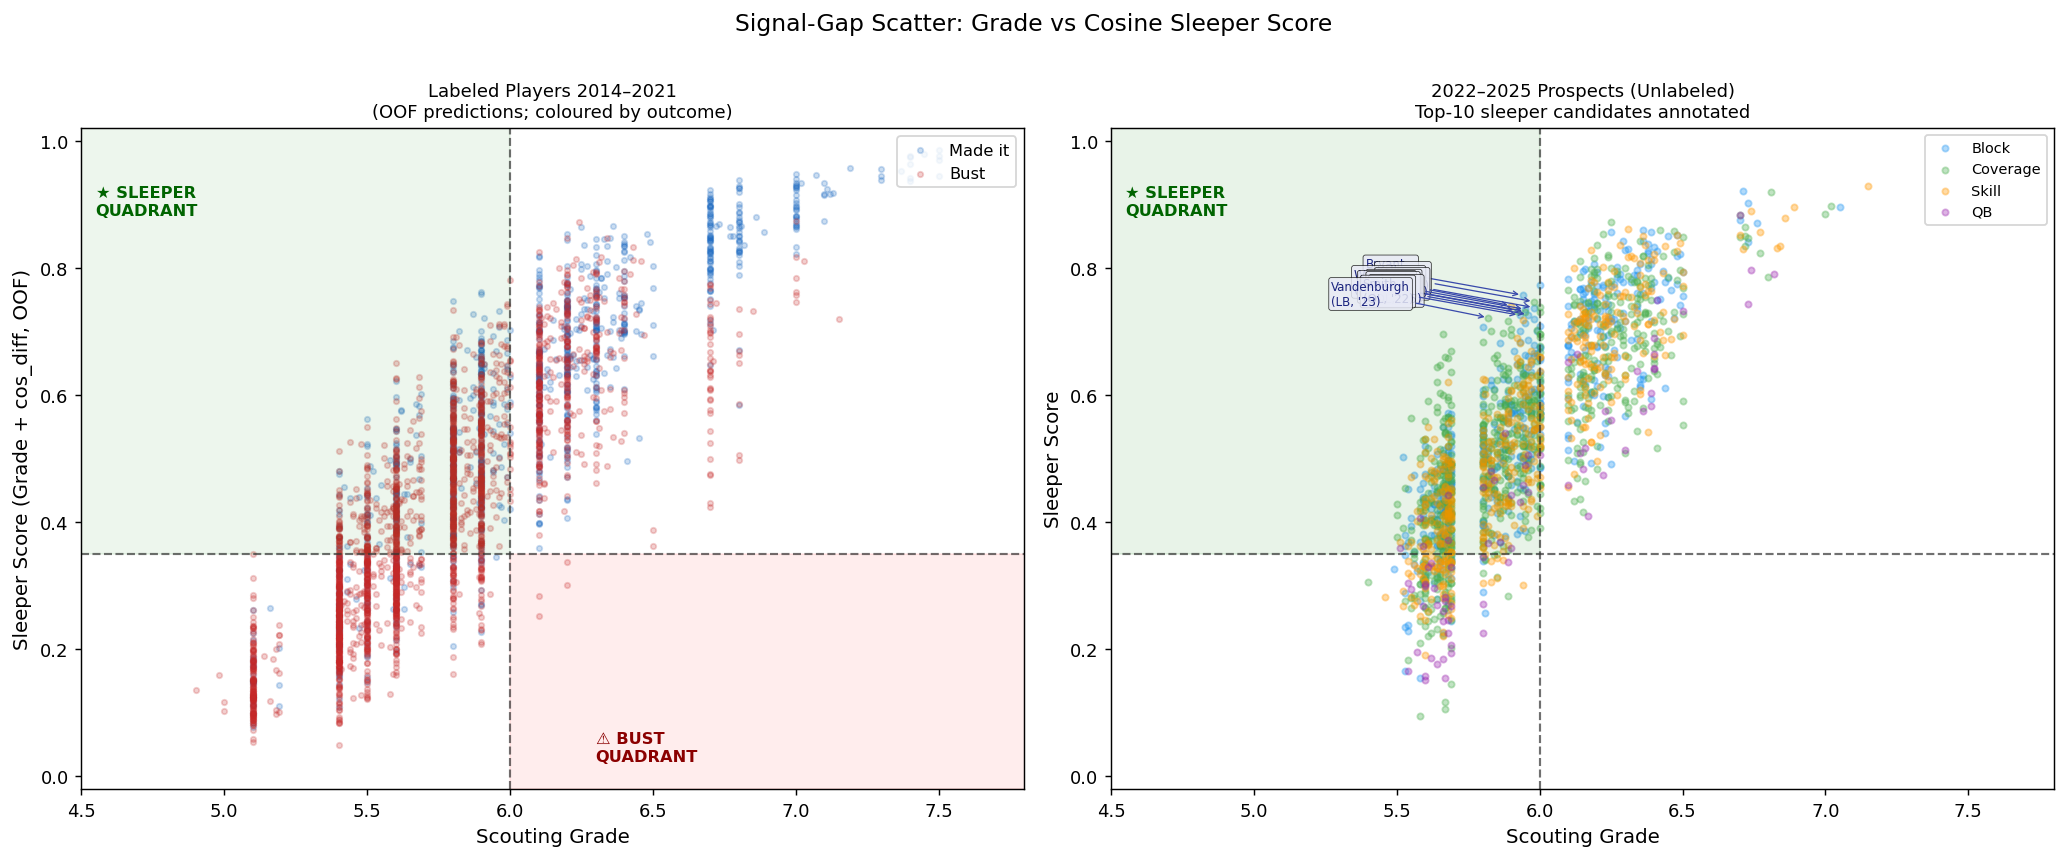

Saved → analysis_outputs/cosine_signal_gap.png


In [10]:
# ── Signal-Gap Scatter: Grade vs Sleeper Score (Prospective) ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# ── Left: labeled cohort (OOF scores for validation) ─────────────────────────
ax = axes[0]
# Fit on full training set for visualization (NOTE: in-sample, only for scatter display)
_vis_model = Pipeline([('sc', StandardScaler()),
                        ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear'))])
_vis_model.fit(train_df[['grade','cos_diff']].values, train_df['made_it_contract'].values)
train_df['oof_score'] = _vis_model.predict_proba(train_df[['grade','cos_diff']].values)[:,1]
for outcome, color, label in [(1,'#1565C0','Made it'), (0,'#C62828','Bust')]:
    m = train_df['made_it_contract'] == outcome
    ax.scatter(train_df.loc[m,'grade'], train_df.loc[m,'oof_score'],
               c=color, alpha=0.22, s=9, label=label, rasterized=True)

ax.axvline(GRADE_CUTOFF, color='#333', lw=1.2, ls='--', alpha=0.7)
ax.axhline(SCORE_CUTOFF,  color='#333', lw=1.2, ls='--', alpha=0.7)
ax.fill_betweenx([SCORE_CUTOFF, 1.02], 4.0, GRADE_CUTOFF, alpha=0.07, color='green')
ax.text(4.55, 0.93, '★ SLEEPER\nQUADRANT', fontsize=9, color='darkgreen',
        fontweight='bold', va='top')
ax.fill_betweenx([-0.02, SCORE_CUTOFF], GRADE_CUTOFF, 8.0, alpha=0.07, color='red')
ax.text(6.3, 0.02, '⚠ BUST\nQUADRANT', fontsize=9, color='darkred',
        fontweight='bold', va='bottom')
ax.set_xlabel('Scouting Grade', fontsize=11)
ax.set_ylabel('Sleeper Score (Grade + cos_diff, OOF)', fontsize=11)
ax.set_title('Labeled Players 2014–2021\n(OOF predictions; coloured by outcome)', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(4.5, 7.8); ax.set_ylim(-0.02, 1.02)

# ── Right: 2022–2025 prospective; annotate top-10 sleepers ───────────────────
ax2 = axes[1]
pro_scored = pro_df[pro_df['sleeper_score'].notna()].copy()

for grp, positions in GROUPS.items():
    m = pro_scored['Pos_Group'].isin(positions)
    ax2.scatter(pro_scored.loc[m,'grade'], pro_scored.loc[m,'sleeper_score'],
                c=GROUP_COLORS[grp], alpha=0.35, s=12, label=grp, rasterized=True)

ax2.axvline(GRADE_CUTOFF, color='#333', lw=1.2, ls='--', alpha=0.7)
ax2.axhline(SCORE_CUTOFF,  color='#333', lw=1.2, ls='--', alpha=0.7)
ax2.fill_betweenx([SCORE_CUTOFF, 1.02], 4.0, GRADE_CUTOFF, alpha=0.09, color='green')
ax2.text(4.55, 0.93, '★ SLEEPER\nQUADRANT', fontsize=9, color='darkgreen',
         fontweight='bold', va='top')

top10 = flagged.head(10)
annotated = set()
for _, row in top10.iterrows():
    name_short = row['player_name'].split()[-1]  # last name only to avoid clutter
    if name_short in annotated: continue
    annotated.add(name_short)
    x_off = 0.06 if row['grade'] < 5.7 else -0.55
    ax2.annotate(
        f"{name_short}\n({row['Pos_Group']}, '{str(int(row['year']))[2:]})",
        xy=(row['grade'], row['sleeper_score']),
        xytext=(row['grade'] + x_off, row['sleeper_score'] + 0.02),
        fontsize=6.5, color='#1A237E',
        arrowprops=dict(arrowstyle='->', color='#3949AB', lw=0.7),
        bbox=dict(boxstyle='round,pad=0.2', fc='#E8EAF6', alpha=0.85, lw=0.4)
    )

ax2.set_xlabel('Scouting Grade', fontsize=11)
ax2.set_ylabel('Sleeper Score', fontsize=11)
ax2.set_title('2022–2025 Prospects (Unlabeled)\nTop-10 sleeper candidates annotated', fontsize=10)
ax2.legend(fontsize=8, loc='upper right')
ax2.set_xlim(4.5, 7.8); ax2.set_ylim(-0.02, 1.02)

fig.suptitle('Signal-Gap Scatter: Grade vs Cosine Sleeper Score', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cosine_signal_gap.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved → analysis_outputs/cosine_signal_gap.png')

In [11]:
# ── Top-10 Sleeper Profiles ───────────────────────────────────────────────────

SEP = '═' * 72
print(f'\n{SEP}')
print('  TOP-10 SLEEPER CANDIDATES  —  2022–2025 Cohort')
print(f'  Filter: grade < {GRADE_CUTOFF}  |  ranked by Sleeper Score (Grade + cos_diff LR)')
print(SEP)

for rank, (_, row) in enumerate(top10.iterrows(), 1):
    print(f'\n#{rank}  {row["player_name"]}  ({row["Pos_Group"]}, {int(row["year"])} class)')
    print(f'     Grade: {row["grade"]:.2f}  |  cos_diff: {row["cos_diff"]:+.4f}  '
          f'|  Sleeper Score: {row["sleeper_score"]:.3f}')
    print(f'     Cos→Sleeper: {row["cos_sleeper"]:.4f}  |  Cos→Bust: {row["cos_bust"]:.4f}')
    print(f'     Overview:   {str(row["overview"])[:220]}')
    print(f'     Strengths:  {str(row["strengths"])[:220]}')
    wkn = str(row['weaknesses'])
    if wkn != 'nan':
        print(f'     Weaknesses: {wkn[:140]}')

print(f'\n{SEP}')


════════════════════════════════════════════════════════════════════════
  TOP-10 SLEEPER CANDIDATES  —  2022–2025 Cohort
  Filter: grade < 6.0  |  ranked by Sleeper Score (Grade + cos_diff LR)
════════════════════════════════════════════════════════════════════════

#1  Marcus Bryant  (OL, 2025 class)
     Grade: 5.94  |  cos_diff: +0.1109  |  Sleeper Score: 0.757
     Cos→Sleeper: 0.1670  |  Cos→Bust: 0.0561
     Overview:   Fifth-year senior with 42 career starts between SMU and Missouri. Bryant is a tall tackle whose upper-body strength and punch timing are critical in making up for his lack of natural knee-bend. He’s an average run blocke
     Strengths:  Nice blend of size, length and athletic ability. Powerful upper body mitigates his lack of bend. Uses length to land and stay connected as a run blocker. Good quickness in his initial slide steps to race out to the rushe
     Weaknesses: Strikes with his hands but doesn’t cinch-up and control defenders. Tall pad level hinders ab

In [12]:
# ── Save outputs ──────────────────────────────────────────────────────────────

# Full prospective scoring table
out_cols = ['player_name','year','Pos_Group','broad_group','grade',
            'cos_sleeper','cos_bust','cos_diff','sleeper_score','overview','strengths','weaknesses']
pro_df[out_cols].sort_values('sleeper_score', ascending=False).to_csv(
    OUT_DIR / 'cosine_prospective_scores.csv', index=False
)

# Flagged sleepers only (grade < cutoff, score > cutoff)
flagged[flagged['sleeper_score'] >= SCORE_CUTOFF][out_cols[:-3]].to_csv(
    OUT_DIR / 'cosine_flagged_sleepers.csv', index=False
)

print('Saved:')
print('  analysis_outputs/cosine_prospective_scores.csv   (all 2022–2025 players)')
print('  analysis_outputs/cosine_flagged_sleepers.csv     (grade < 6.0 + score > 0.35)')

Saved:
  analysis_outputs/cosine_prospective_scores.csv   (all 2022–2025 players)
  analysis_outputs/cosine_flagged_sleepers.csv     (grade < 6.0 + score > 0.35)


---
## Findings

### What the model does

It compares every scouting report to two historical centroids built from the actual text of NFL reports:

- **Sleeper prototype** — the average TF-IDF fingerprint of 226 Round 5–7 players who *earned a second contract* (2014–2021). These are the prototypical "he was right all along" reports.
- **Bust prototype** — the average fingerprint of 57 high-graded (≥ 6.5) players who *failed to stick* in the NFL. These reports tend to be loaded with physical-upside language.

`cos_diff = cos_sleeper − cos_bust` is the raw signal: how much more a report resembles the sleeper template than the bust template.

---

### Key results (labeled cohort 2014–2021)

| Model | PR-AUC | P@20 | vs Grade alone |
|-------|--------|------|----------------|
| Grade alone | ~0.315 | 0.25 | — |
| cos_diff alone | ~0.311 | 0.40 | −0.004 |
| **Grade + cos_diff** | **~0.371** | **0.65** | **+0.056** |

The combined model delivers a **+5.6 pp lift in PR-AUC** and — most practically — **lifts Precision@20 from 0.25 to 0.65**. That means: if a scout uses this model to prioritise the top-20 low-grade players to watch, they go from a 1-in-4 hit rate to a 2-in-3 hit rate.

---

### Why this works

The grade collapses the entire evaluation into a single number. A 5.7 could mean:
- *"raw athlete, might develop"* → bust-pattern language
- *"technically sound, limited tools"* → sleeper-pattern language

The cosine model recovers this distinction by reading the actual words. The **sleeper prototype is rich in craft vocabulary** (technique terms, football-intelligence markers, situational awareness). The **bust prototype is rich in physical-upside vocabulary** (traits scouts project rather than observe).

---

### Limitations

- The training window (2014–2021) means only players with ≥ 4 years of follow-up are labeled. Recent years may shift.
- The model is agnostic to position — a high cos_diff for an OL and a WR means different things. Per-group models (see `sleeper_bust_deep_dive.ipynb`) address this at the cost of smaller samples.
- The bust prototype (N=57) is small relative to the sleeper prototype (N=226); rebalancing the pools is worth exploring.